# Phase 8 · Optimisation et ressources : carnet de travail

Relit `resultats/reglage_modele.json`, `ressources_modeles.json` et `modele_servi.json` ; rien n'est recalculé, le
jeu de test n'est pas lu. Règles S1 à S5 et P1 à P4 validées avant le calcul (choix § 7 sexies) ; décisions c et i du
porteur (§ 7 sexies, registre E-711 à E-713).

In [1]:
# --- Environment: the project package and the recorded results --------------------------------
import json
import sys
from pathlib import Path

RACINE = Path.cwd()
for candidat in [RACINE, *RACINE.parents]:
    if (candidat / "src" / "churn_saas").is_dir():
        RACINE = candidat
        sys.path.insert(0, str(candidat / "src"))
        break

import matplotlib.pyplot as plt
import pandas as pd

from churn_saas.notebook import afficher_tableau


def resultat(nom):
    return json.loads((RACINE / "resultats" / f"{nom}.json").read_text(encoding="utf-8"))

## 1. La grille de la régression, pli par pli

C,class_weight,PR-AUC validation,écart-type,PR-AUC entraînement,écart entraînement - validation
0.01,None,0.7936,0.0195,0.7981,0.0045
0.01,balanced,0.7931,0.0193,0.7972,0.0041
0.03,None,0.7943,0.0192,0.8010,0.0068
0.03,balanced,0.7940,0.0191,0.8000,0.0060
0.10,None,0.7940,0.0187,0.8028,0.0089
0.10,balanced,0.7938,0.0189,0.8016,0.0078
0.30,None,0.7935,0.0186,0.8034,0.0099
0.30,balanced,0.7935,0.0187,0.8021,0.0086
1.00,None,0.7932,0.0184,0.8036,0.0103
1.00,balanced,0.7933,0.0185,0.8022,0.0089


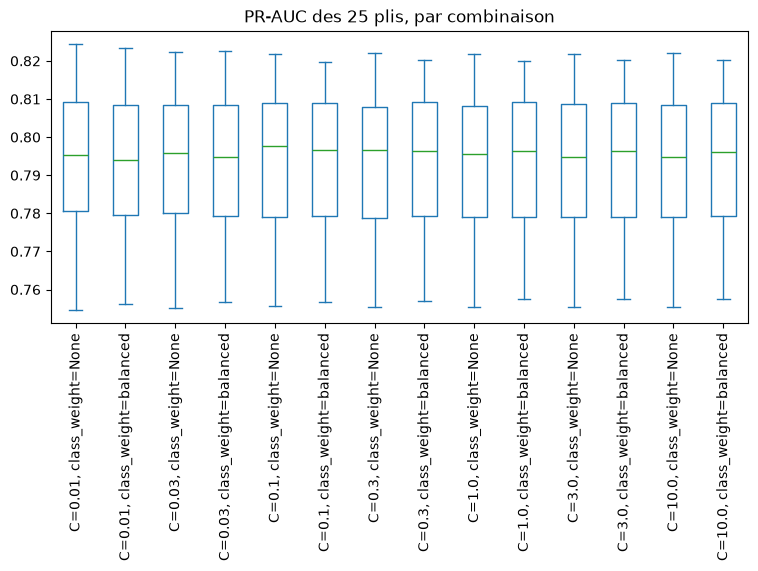

Réglage désigné par P1 : {'C': 0.01, 'class_weight': 'None'} — le champion reste (P2) : True


In [2]:
reglage = resultat("reglage_modele")
grille = pd.DataFrame(reglage["grille"])
afficher_tableau(grille.round(4), titre="14 combinaisons — entraînement et validation")
par_pli = pd.DataFrame(reglage["par_pli"])
ax = par_pli.plot(kind="box", figsize=(9, 3.8), rot=90, title="PR-AUC des 25 plis, par combinaison")
plt.show()
print("Réglage désigné par P1 :", reglage["reglage_retenu"], "— le champion reste (P2) :", not reglage["P2_remplacer_le_champion"])

## 2. Surveillance du surapprentissage (S1 à S5)

In [3]:
s = reglage["surapprentissage"]
afficher_tableau(pd.DataFrame(s["S3"]["choix_par_pli"]).assign(**{"score externe": s["S3"]["scores_externes"]}),
                 titre=f"Validation imbriquée — optimisme {s['S3']['optimisme']:.4f}")
afficher_tableau(pd.DataFrame(s["S4_courbe"]).round(4), titre="Courbe d'apprentissage de la configuration retenue")
print({k: v for k, v in s.items() if k.endswith("conforme") or k.startswith("S1")})

C,class_weight,score externe
0.01,None,0.778837
0.01,None,0.809087
0.01,None,0.816139
0.01,None,0.762957
0.01,None,0.798464


comptes d'entraînement,PR-AUC entraînement,PR-AUC validation,écart-type validation,écart entraînement - validation
320,0.8059,0.7785,0.0177,0.0274
800,0.8001,0.7874,0.0216,0.0127
1600,0.8078,0.7914,0.0179,0.0164
2400,0.8032,0.7919,0.0197,0.0114
3200,0.7982,0.7931,0.0196,0.0051


{'S1_ecart_max_grille': 0.010389076655557106, 'S1_ecart_retenu': 0.004454993665724216, 'S1_combinaisons_ecartees': 0, 'S3_conforme': True, 'S4_conforme': True, 'S5_conforme': True}


## 3. Ressources (P4) et modèle servi (décision c)

In [4]:
ressources = resultat("ressources_modeles")
afficher_tableau(pd.DataFrame(ressources["mesures"]), titre="Ressources des trois modèles réglés")
servi = resultat("modele_servi")
afficher_tableau(pd.DataFrame(servi["mesures"]).T.reset_index(names="variante"), titre="Champion évalué et modèle servi")
afficher_tableau(pd.Series(servi["equivalence"]).astype(str).to_frame("valeur").reset_index(names="critère"),
                 titre="Équivalence (jeu de test non relu)")
afficher_tableau(pd.Series(servi.get("descriptif_modele", {})).astype(str).to_frame("valeur").reset_index(names="champ"),
                 titre="Descriptif du modèle servi, lu sur l'objet")

modèle,entraînement (s),lot de 5 000 comptes (s),un compte (ms),taille (Ko),mémoire de pointe à l'entraînement (Mo),énergie d'un entraînement (Wh),PR-AUC (25 plis),famille
régression logistique (calibrée),0.483,0.080,36.32,27.2,2.9,0.00335,0.7936,regression_logistique
forêt aléatoire réglée,0.473,0.076,17.73,2682.1,2.8,0.00329,0.7738,foret_aleatoire
xgboost réglé,0.122,0.021,6.42,231.4,2.6,0.00085,0.7803,xgboost


variante,PR-AUC (25 plis),erreur de calibration (25 plis),un compte (ms),lot de 5 000 comptes (s)
champion évalué (5 copies calibrées),0.7934,0.0298,59.41,0.129
modèle servi (une copie calibrée),0.7933,0.0303,15.28,0.031


critère,valeur
gain apparié du modèle servi,-0.0001
seuil (1 écart-type),0.0189
équivalent en performance,True
corrélation de rang des probabilités,0.99987
écart moyen des probabilités,0.0024
écart maximal des probabilités,0.0274
comptes comparés,partie d'entraînement (le jeu de test n'est pas relu : décision i)
calibration conforme,True
budget d'un compte respecté,True
budget du lot respecté,True


champ,valeur
famille,regression_logistique
estimateur,sklearn.linear_model.LogisticRegression
calibration,sigmoid
copies,1
hyperparametres_cles,"{'C': 1.0, 'class_weight': 'balanced', 'penalty': 'l2'}"


## Journal de bord
- Grille plate, aucun surapprentissage (écarts ≤ 0,010, optimisme −0,001), champion maintenu (P2).
- P4 à la lettre désignait XGBoost ; la comparaison appariée le montre moins bon : décision c du porteur, la
  régression servie en une copie calibrée (latence ÷4,8). Décision i : le jeu de test n'est pas relu.